In [1]:
import sys

sys.argv = [
    "ipykernel_launcher.py",  
    "--dataset", "CustomAWGN30ES15",  # Ensure value is provided
    "--model", "",
    "--Device", "cpu",
    "--test"  # This is a flag, so no value needed
]

In [2]:
import pickle
import os
import pandas as pd
import numpy as np
import sqlite3
from tqdm import tqdm
import copy

from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader, TensorDataset

import sklearn
from scipy.signal import resample
from src.models import *
from src.utils import *
from main import  load_dataset, backprop

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

def normalize3(a, min_a=None, max_a=None):
    if min_a is None: min_a, max_a = np.min(a, axis=0), np.max(a, axis=0)
    return ((a - min_a) / (max_a - min_a + 0.0001)), min_a, max_a

def denormalize3(a_norm, min_a, max_a):
    return a_norm * (max_a - min_a + 0.0001) + min_a

def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)

def convert_to_windows(data, model):
    windows = []
    w_size = model.n_window
    for i, g in enumerate(data):
        if i >= w_size:
            w = data[i - w_size:i]  # cut
        else:
            w = torch.cat([data[0].repeat(w_size - i, 1), data[0:i]])  # pad
        windows.append(w if 'DTAAD' in model.name or 'Attention' in model.name or 'TranAD' in model.name else w.view(-1))
    return torch.stack(windows)

def load_model(modelname, dims):
    import src.models
    model_class = getattr(src.models, modelname)
    model = model_class(dims).double()
    fname = f'checkpoints/{model.name}_{args.dataset}/model.ckpt'
    if os.path.exists(fname) and (not args.retrain or args.test):
        checkpoint = torch.load(fname, weights_only=False, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        print(f"{color.GREEN}Creating new model: {model.name}{color.ENDC}")
        assert True
    return model

def filter_noise_es(df, alpha=0.4, reduction=False):
    import copy
    new_df = copy.deepcopy(df)
    
    for column in df:
        new_df[column] = df[column].ewm(alpha=alpha, adjust=False).mean()
    
    if reduction:
        return new_df[::len(df)]  # Adjust sparsity if needed
    else:
        return new_df

def wgn_pandas(df_withtime, snr, alpha=0.15, window_size=120):
    df_no_timestamp = df_withtime.drop(columns=['TimeStamp'])
    noisy_df = pd.DataFrame(index=df_no_timestamp.index, columns=df_no_timestamp.columns)

    for start in range(0, len(df_no_timestamp), window_size):
        window = df_no_timestamp.iloc[start:start + window_size]
        
        Ps = np.sum(np.power(window, 2), axis=0) / len(window)
        Pn = Ps / (np.power(10, snr / 10))

        noise = np.random.randn(*window.shape) * np.sqrt(Pn.values)
        noisy_window = window + (noise / 100)

        noisy_df.iloc[start:start + window_size] = noisy_window
    
    noisy_df.reset_index(drop=True, inplace=True)
    noisy_df = filter_noise_es(pd.DataFrame(noisy_df, columns=noisy_df.columns), alpha)

    df_timestamp = df_withtime['TimeStamp']
    df_timestamp.reset_index(drop=True, inplace=True)

    df_withtime = pd.concat([df_timestamp, noisy_df], axis=1)
    return df_withtime

def percentage2severity(value):
    return (
        1 if 0 <= value < 5 else
        2 if 5 <= value < 20 else
        3 if 20 <= value < 40 else
        4 if 40 <= value < 75 else
        5 if 75 <= value <= 100 else
        6
    )

def preprocessPD_loadData(df_sel):
    df_sel = wgn_pandas(df_sel, 30, alpha=0.15)

    df_timestamp = df_sel.iloc[:, 0]
    df_feature =  df_sel.iloc[:, 1:]
    df_feature = df_feature[feature_set]

    df_feature, _, _ = normalize3(df_feature, min_a, max_a)
    df_feature = df_feature.astype(float)

    test_loader = DataLoader(df_feature.values, batch_size=df_feature.shape[0])
    testD = next(iter(test_loader))
    testO = testD

    return testD, testO, df_timestamp, df_feature

def calcThres_allModel(threshold_percentages, temp_ypreds, model_array, testD, testO):
    for idx_model, model_now in enumerate(model_array):
        model = load_model(model_now, testO.shape[1])
        model.eval()
        torch.zero_grad = True

        if model.name in ['Attention', 'DAGMM', 'USAD', 'MSCRED', 
                            'CAE_M', 'GDN', 'MTAD_GAT', 'MAD_GAN', 'TranAD'] or 'DTAAD' in model.name:
            testD_now = convert_to_windows(testD, model)
        else:
            testD_now = testD

        loss, y_pred = backprop(0, model, testD_now, testO, None, None, training=False)

        threshold_pass = {}
        for idx_feat in range(loss.shape[-1]):
            thres_bool = loss[:, idx_feat] > model_thr[model_now][idx_feat]
            threshold_pass[feature_set[idx_feat]] = (thres_bool.sum() / thres_bool.shape[0]) * 100
        
        threshold_percentages[idx_model] = threshold_pass
        temp_ypreds[idx_model] = denormalize3(y_pred, min_a, max_a)

    return threshold_percentages, temp_ypreds

def calc_counterPercentage(threshold_percentages):
    counter_feature = {}
    for modex_idx, values_pred in threshold_percentages.items():
        values_pred = dict(sorted(values_pred.items(), key=lambda item: item[1], reverse=True)[:10])
        for name_feat, percentage in values_pred.items():
            if name_feat in counter_feature:
                counter_feature[name_feat]["count"] = counter_feature[name_feat]["count"] + 1
                counter_feature[name_feat]["percentage"] = counter_feature[name_feat]["percentage"] + percentage
            else:
                counter_feature[name_feat] = {"count": 1, "percentage": percentage}

    counter_feature_s1 = dict(sorted(counter_feature.items(), key=lambda item: item[1]['count'], reverse=True)[:10])
    counter_feature_s2 = dict(sorted(counter_feature_s1.items(), key=lambda item: item[1]['percentage'] // len(model_array), reverse=True))
    #counter_feature_s2_rank = dict(sorted(counter_feature_s1.items(), key=lambda item: item[1]['count'], reverse=True))

    for key, value in counter_feature_s2.items():
        counter_feature_s2[key]['count'] = (counter_feature_s2[key]['count'] / len(model_array)) * 100
        counter_feature_s2[key]['severity'] = percentage2severity(counter_feature_s2[key]['percentage'] // len(model_array))
        counter_feature_s2[key]['percentage'] = (counter_feature_s2[key]['percentage'] // len(model_array))

    # Find Which Model Have Highest Confidence
    counter_feature_plot = {}
    for index, value in counter_feature_s2.items():
        higher_data = {"model": 0, "percentage": 0}
        for model_idx in threshold_percentages:
            if index in threshold_percentages[model_idx]:
                if higher_data["percentage"] <= threshold_percentages[model_idx][index]:
                    higher_data["model"] = model_idx
                    higher_data["percentage"] = threshold_percentages[model_idx][index]
        
        counter_feature_plot[index] = higher_data['model']

    return counter_feature_s2, counter_feature_plot

def calc_counterPercentageTrending(threshold_percentages):
    counter_feature = {}
    for modex_idx, values_pred in threshold_percentages.items():
        for name_feat, percentage in values_pred.items():
            if name_feat in counter_feature:
                if percentage > 5.0:
                    counter_feature[name_feat]["count"] = counter_feature[name_feat]["count"] + 1
                    counter_feature[name_feat]["percentage"] = counter_feature[name_feat]["percentage"] + percentage
            else:
                counter_feature[name_feat] = {"count": 1, "percentage": percentage}

    for key, value in counter_feature.items():
        counter_feature[key]['count'] = (counter_feature[key]['count'] / len(model_array)) * 100
        if counter_feature[key]['count'] >= 20.0:
            counter_feature[key]['severity'] = percentage2severity(counter_feature[key]['percentage'] // len(model_array))
            counter_feature[key]['percentage'] = (counter_feature[key]['percentage'] // len(model_array))
        else:
            counter_feature[key]['severity'] = 1
            counter_feature[key]['percentage'] = 0.0

    return counter_feature

def do_plotSeverityRank():
    fig = plt.figure(figsize=(16, 8))
    gs = GridSpec(4, 3, figure=fig)

    feature_index_list = [feature_set.index(feat_name) for feat_name in list(counter_feature_s2.keys())]
    for idx, (feature_index_now) in enumerate(feature_index_list[:4]):
        model_idx_highest = counter_feature_plot[feature_set[feature_index_now]]

        ax = fig.add_subplot(gs[idx, :2])
        ax.plot(df_timestamp, temp_ypreds[model_idx_highest][:, idx], color='blue', label='Prediction')
        ax.plot(df_timestamp, df_feature[:, idx], color='red', label='Original')
        ax.set_title(feature_set[feature_index_now])
        ax.legend() 
        ax.grid(True)

    date_format = DateFormatter("%d/%m/%Y - %H:%M")  # Define the desired format
    plt.gca().xaxis.set_major_formatter(date_format)
    plt.gcf().autofmt_xdate()

    y2 = list(counter_feature_s2.keys())
    x2 = [value['severity'] for value in counter_feature_s2.values()]
    x2_c = [value['count'] for value in counter_feature_s2.values()]

    norm_x2 = [(val - 1) / 5 for val in x2]
    cmap = LinearSegmentedColormap.from_list('severity_colormap', ['green', 'yellow', 'red'])
    colors = [cmap(norm) for norm in norm_x2]

    ax3 = fig.add_subplot(gs[:3, 2])
    bars = ax3.barh(y2, x2, color=colors)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=6))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax3, orientation='vertical', label='Severity')

    for bar, perc in zip(bars, x2_c):
        width = bar.get_width()  # Get the width of the bar
        ax3.text(
            width - 0.1,             # X-coordinate (inside the bar, near the right edge)
            bar.get_y() + bar.get_height() / 2,  # Y-coordinate (center of the bar)
            f"{int(perc)}%",            # Text label (percentage with % sign)
            va='center',           # Vertical alignment
            ha='right',            # Horizontal alignment
            color='black',         # Text color for visibility
            fontsize=9            # Font size
        )
    ax3.invert_yaxis()
    ax3.set_xticks(range(1, 8))
    ax3.set_ylabel("Parameter")
    ax3.set_xlabel("Severity")
    ax3.set_title("Severity Rank")

    #fig.suptitle(f"{df_anomaly_unplaned.values[failure_index_list, 4]}_{df_anomaly_unplaned.values[failure_index_list, 0]}", fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    return fig

def init_db(feature_set, db_name="masters_data.db", table_name="severity_trending"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Create table if it does not exist
    columns = ", ".join([feature_name.replace(" ", "_") for feature_name in feature_set])
    cursor.execute(f"""
        CREATE TABLE IF NOT EXISTS {table_name} (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            {columns}
        )
    """)

    conn.commit()
    conn.close()

def init_db_timeconst(feature_set, db_name="masters_data.db", table_name="severity_trending"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Create table if it does not exist
    columns = ", ".join([feature_name.replace(" ", "_") for feature_name in feature_set])
    cursor.execute(f"""
        CREATE TABLE IF NOT EXISTS {table_name} (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            {columns}
        )
    """)

    conn.commit()
    conn.close()

def trend_savedb(data, feature_set, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    timestamp = datetime.now().replace(second=0, microsecond=0).isoformat()
    cursor.execute(f"""
        INSERT INTO {table_name} (timestamp, {', '.join([feature_name.replace(" ", "_") for feature_name in feature_set])})
        VALUES (?, {', '.join(['?' for _ in range(len(feature_set))])})
    """, (timestamp, *data))
    
    conn.commit()
    conn.close()

def timeseries_savedb(df_timestamp, data, feature_set, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    # Generate timestamp
    timestamp = df_timestamp.isoformat()
    
    # Build column names for features, replacing spaces with underscores
    feature_columns = ', '.join([feature_name.replace(" ", "_") for feature_name in feature_set])
    placeholders = ', '.join(['?' for _ in range(len(feature_set))])
    
    # Upsert using INSERT OR REPLACE
    # Note: Your table must have a UNIQUE constraint on the timestamp column.
    sql = f"""
        INSERT OR REPLACE INTO {table_name} (timestamp, {feature_columns})
        VALUES (?, {placeholders})
    """
    cursor.execute(sql, (timestamp, *data))
    
    conn.commit()
    conn.close()

def batch_timeseries_savedb(df_timestamps, data, feature_set, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    # Convert timestamps to ISO format
    timestamps = [pd.to_datetime(ts).isoformat() for ts in df_timestamps]
    
    # Build column names for features, replacing spaces with underscores
    feature_columns = ', '.join([feature_name.replace(" ", "_") for feature_name in feature_set])
    placeholders = ', '.join(['?' for _ in range(len(feature_set)+1)])  # 30 features + 1 timestamp
    
    # Prepare batch data
    batch_data = [(timestamps[i], *data[i]) for i in range(data.shape[0])]
    
    # Upsert using INSERT OR REPLACE (Ensure UNIQUE constraint on timestamp in your DB schema)
    sql = f"""
        INSERT OR REPLACE INTO {table_name} (timestamp, {feature_columns})
        VALUES ({placeholders})
    """
    
    cursor.executemany(sql, batch_data)
    conn.commit()
    conn.close()

def fetch_between_dates(start_date, end_date, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    cursor.execute(f"""
        SELECT * FROM {table_name} WHERE timestamp BETWEEN ? AND ?
    """, (start_date, end_date))
    
    rows = cursor.fetchall()
    conn.close()

    if not rows:
        return np.array([])
    
    return np.array(rows)

def convert_timestamp(timestamp_str):
    dt = datetime.fromisoformat(timestamp_str)
    return pd.Timestamp(dt.strftime('%Y-%m-%d %H:%M:%S'))

In [3]:
feature_set = ['Active Power', 'Reactive Power', 'Governor speed actual', 'UGB X displacement', 'UGB Y displacement',
    'LGB X displacement', 'LGB Y displacement', 'TGB X displacement',
    'TGB Y displacement', 'Stator winding temperature 13',
    'Stator winding temperature 14', 'Stator winding temperature 15',
    'Surface Air Cooler Air Outlet Temperature',
    'Surface Air Cooler Water Inlet Temperature',
    'Surface Air Cooler Water Outlet Temperature',
    'Stator core temperature', 'UGB metal temperature',
    'LGB metal temperature 1', 'LGB metal temperature 2',
    'LGB oil temperature', 'Penstock Flow', 'Turbine flow',
    'UGB cooling water flow', 'LGB cooling water flow',
    'Generator cooling water flow', 'Governor Penstock Pressure',
    'Penstock pressure', 'Opening Wicked Gate', 'UGB Oil Contaminant',
    'Gen Thrust Bearing Oil Contaminant']

with open('normalize_2023.pickle', 'rb') as handle:
    normalize_obj = pickle.load(handle)
    min_a, max_a = normalize_obj['min_a'], normalize_obj['max_a']

model_array = ["Attention", "DTAAD", "MAD_GAN", "TranAD", "DAGMM", "USAD", "OmniAnomaly"] # , CAE_M "GDN" MSCRED
model_thr = {}
for model_name in model_array:
    model_thr[model_name] = 0

for model_now in model_array:
    with open(f'loss_fold/{args.dataset}/{model_now}.pickle', 'rb') as handle:
        loss = pickle.load(handle)
    model_thr[model_now] = [np.percentile(loss[:, index], 99) for index in range(len(feature_set))]

measured_horizon = 60 * 2 * 1

init_db_timeconst(feature_set, "db/original_data.db", "original_data")
init_db_timeconst(['Grid Selection'], "db/original_data.db", "additional_original_data")
init_db_timeconst(feature_set, "db/severity_trendings.db", "severity_trendings")
init_db_timeconst(feature_set, "db/severity_trendings.db", "original_sensor")
for model_name in model_array:
    init_db_timeconst(feature_set, "db/pred_data.db", model_name)
    init_db_timeconst(feature_set, "db/threshold_data.db", model_name)

In [4]:
df_data_withtime = pd.read_pickle("/run/media/fourier/Data2/Pras/Vale/time-series-autoencoder/my_data_5thn_olah.pickle")
mask = (df_data_withtime['TimeStamp'] >= '2020-01-01 00:00:00')
df_data_withtime = df_data_withtime.loc[mask]

df_data_withtime = df_data_withtime[['TimeStamp'] + feature_set] 

for column_name in df_data_withtime.columns:
    if column_name != 'Load_Type' and column_name != 'TimeStamp':
        df_data_withtime[column_name] = pd.to_numeric(df_data_withtime[column_name], downcast='float')
        
df_anomaly = pd.read_excel("/run/media/fourier/Data2/Pras/Vale/time-series-autoencoder/shutdown_list.xlsx", 'Sheet2')
df_anomaly['Start Time'] = pd.to_datetime(df_anomaly['Start Time'])
df_anomaly['End Time'] = pd.to_datetime(df_anomaly['End Time'])
df_anomaly_unplaned = df_anomaly.copy()

mask = (df_anomaly_unplaned['Interal/External'] == 'Internal') & (df_anomaly_unplaned['Shutdown Type'] == 'Unplanned') & (df_anomaly_unplaned['Start Time'] >= '2020-01-01 00:00:00')
df_anomaly_unplaned = df_anomaly_unplaned.loc[mask]
df_anomaly_unplaned = df_anomaly_unplaned.reset_index(drop=True)
df_anomaly_unplaned = df_anomaly_unplaned.drop(df_anomaly_unplaned.index[[2]])
df_anomaly_unplaned = df_anomaly_unplaned.reset_index(drop=True)
df_anomaly_unplaned

,Start Time,End Time,Event,Activities,Related Component,Action/Cause,Interal/External,Shutdown Details,Startup Details,Supplied Grid after Action,Shutdown Type
0,2023-05-22 20:13:00,2023-05-22 20:32:00,LGS#1 Trip by 86N energized,Mechanical,TGB Oil Level,Repairment,Internal,Trip by 86 N Alarm,Flying Started,FCE Grid,Unplanned
1,2022-03-26 10:07:00,2022-03-26 13:50:00,LGS#1 Trip by 86N energized,Mechanical,Rotor Shaft Current at Lower Generator,Repairment,Internal,Trip by 86N Alarm to Standstill,Start via 4/CS,FCE Grid,Unplanned
2,2021-05-28 06:15:00,2021-05-30 00:58:00,LGS#1 Trip by 86N energized,Mechanical,TGB Cooling Water,Repairment,Internal,Trip by 86N Alarm,Started via 4/CS,FCE Grid,Unplanned


In [5]:
df_numeric = df_data_withtime.drop(columns=['TimeStamp'])
correlation_matrix = df_numeric.corr().abs()

result = {}

for column in correlation_matrix.columns:
    top_corr = (
        correlation_matrix[column]
        .drop(labels=[column])  # exclude self-correlation
        .abs()  # use absolute value to rank
        .sort_values(ascending=False)
        .head(15)
    )

    # Add to result dict with actual correlation values (not abs)
    result[column] = [
        {other_col: f"{correlation_matrix.at[other_col, column]:.2f}"}
        for other_col in top_corr.index
    ]

# Example output
print(result['Active Power'])

[{'Opening Wicked Gate': '0.99'}, {'Turbine flow': '0.99'}, {'Penstock Flow': '0.94'}, {'Surface Air Cooler Air Outlet Temperature': '0.63'}, {'Stator winding temperature 15': '0.61'}, {'Surface Air Cooler Water Inlet Temperature': '0.60'}, {'Surface Air Cooler Water Outlet Temperature': '0.58'}, {'Stator winding temperature 14': '0.58'}, {'Reactive Power': '0.56'}, {'UGB Oil Contaminant': '0.54'}, {'Governor speed actual': '0.54'}, {'Governor Penstock Pressure': '0.54'}, {'LGB X displacement': '0.45'}, {'LGB Y displacement': '0.41'}, {'Stator core temperature': '0.40'}]


In [6]:
def label_load(row):
   if row['Active Power'] < 1 and row['Governor speed actual'] < 1:
      return 'Shutdown'
   elif row['Active Power'] < 3 and row['Governor speed actual'] < 250:
      return 'Warming'
   elif row['Active Power'] < 3 and row['Governor speed actual'] > 250:
      return 'No Load'
   elif row['Active Power'] >= 1 and row['Active Power'] < 20 and row['Governor speed actual'] > 250:
      return 'Low Load'
   elif row['Active Power'] >= 20 and row['Active Power'] < 40 and row['Governor speed actual'] > 250:
      return 'Rough Zone'
   elif row['Active Power'] >= 40 and row['Active Power'] < 50 and row['Governor speed actual'] > 250:
      return 'Part Load'
   elif row['Active Power'] >= 50 and row['Active Power'] < 65 and row['Governor speed actual'] > 250:
      return 'Efficient Load'
   elif row['Active Power'] >= 65 and row['Governor speed actual'] > 250:
      return 'High Load'
   else:
      return 'Undefined'

In [ ]:
df_data_withtime['Load Label'] = df_data_withtime.apply(label_load, axis=1)

# Step 2: Convert datetime column to proper format if not already
df_data_withtime['TimeStamp'] = pd.to_datetime(df_data_withtime['TimeStamp'])  # Replace with actual datetime column name
df_data_withtime = df_data_withtime.sort_values('TimeStamp')

# Step 3: Resample to hourly blocks, getting the most frequent label (mode) in each hour
hourly_labels = df_data_withtime.resample('H', on='TimeStamp')['Load Label'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Undefined')

# Step 4: Convert to DataFrame for easier indexing
hourly_df = hourly_labels.reset_index().rename(columns={'Load Label': 'Hour Label'})

In [17]:
# Step 5: Find 2-hour windows that match the criteria
valid_pairs = []
for i in range(len(hourly_df) - 1):
    first_label = hourly_df.loc[i, 'Hour Label']
    second_label = hourly_df.loc[i + 1, 'Hour Label']
    
    if (first_label == 'Efficient Load' and second_label == 'Low Load') or \
       (first_label == 'Low Load' and second_label == 'Efficient Load'):
        valid_pairs.append((hourly_df.loc[i, 'TimeStamp'], hourly_df.loc[i + 1, 'TimeStamp']))

# Output the valid 2-hour windows
for start, end in valid_pairs:
    print(f"Hour 1: {start} | Hour 2: {end}")


Hour 1: 2020-01-05 12:00:00 | Hour 2: 2020-01-05 13:00:00
Hour 1: 2020-01-06 08:00:00 | Hour 2: 2020-01-06 09:00:00
Hour 1: 2020-01-18 14:00:00 | Hour 2: 2020-01-18 15:00:00
Hour 1: 2020-01-30 17:00:00 | Hour 2: 2020-01-30 18:00:00
Hour 1: 2020-02-10 06:00:00 | Hour 2: 2020-02-10 07:00:00
Hour 1: 2020-02-16 15:00:00 | Hour 2: 2020-02-16 16:00:00
Hour 1: 2020-02-16 17:00:00 | Hour 2: 2020-02-16 18:00:00
Hour 1: 2020-02-18 03:00:00 | Hour 2: 2020-02-18 04:00:00
Hour 1: 2020-02-18 10:00:00 | Hour 2: 2020-02-18 11:00:00
Hour 1: 2020-03-19 13:00:00 | Hour 2: 2020-03-19 14:00:00
Hour 1: 2020-03-27 19:00:00 | Hour 2: 2020-03-27 20:00:00
Hour 1: 2020-04-01 09:00:00 | Hour 2: 2020-04-01 10:00:00
Hour 1: 2020-04-22 22:00:00 | Hour 2: 2020-04-22 23:00:00
Hour 1: 2020-04-26 03:00:00 | Hour 2: 2020-04-26 04:00:00
Hour 1: 2020-04-27 11:00:00 | Hour 2: 2020-04-27 12:00:00
Hour 1: 2020-04-30 07:00:00 | Hour 2: 2020-04-30 08:00:00
Hour 1: 2020-04-30 15:00:00 | Hour 2: 2020-04-30 16:00:00
Hour 1: 2020-0

/tmp/ipykernel_1546998/3275906120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel.drop('Load Label', axis=1, inplace=True)


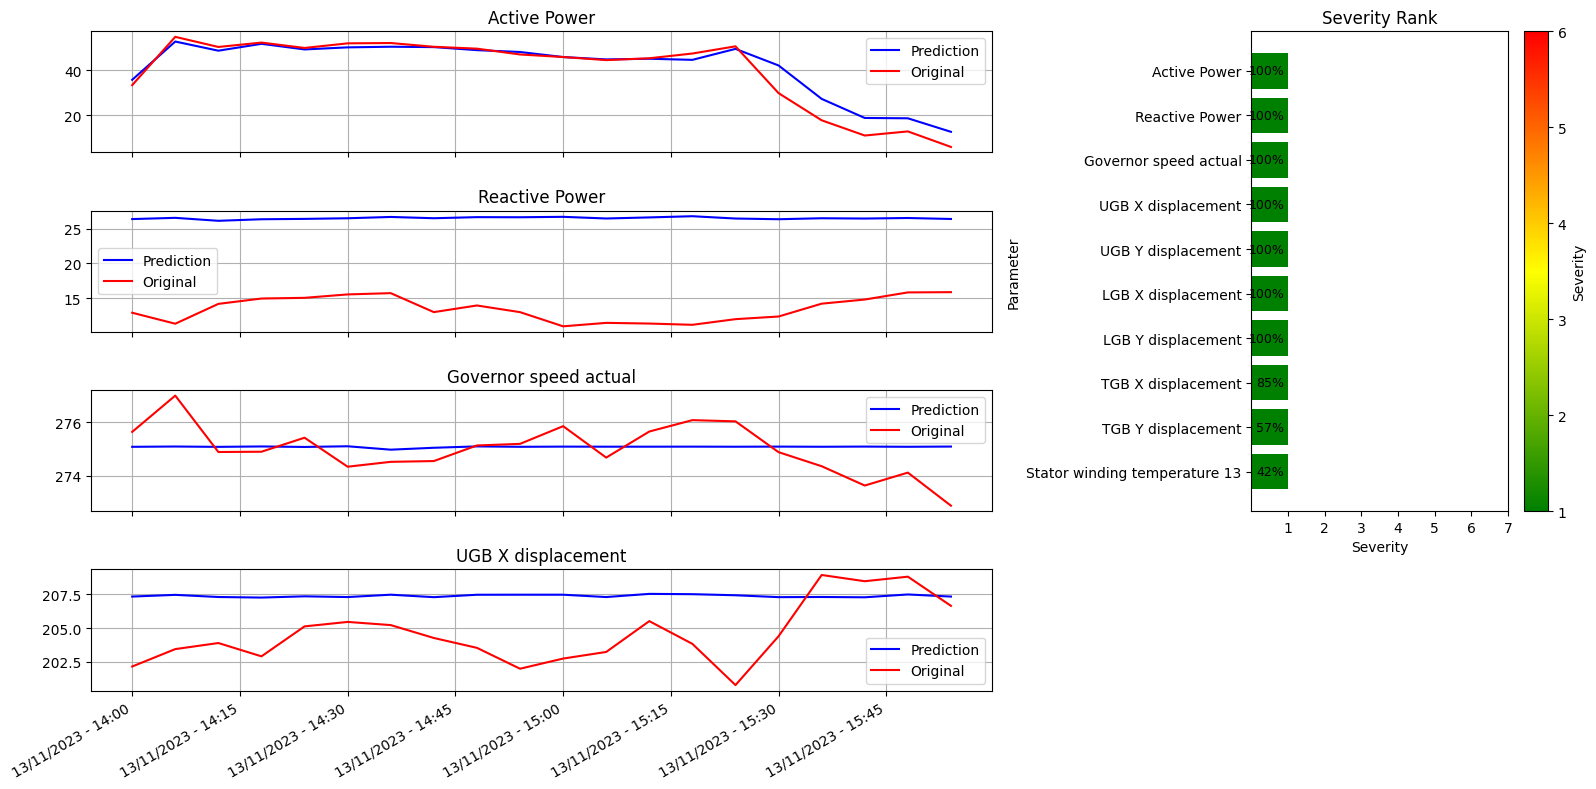

In [42]:
start_time, end_time = valid_pairs[-10]
window_end = end_time + pd.Timedelta(hours=1)

df_sel = df_data_withtime[(df_data_withtime['TimeStamp'] >= start_time) & (df_data_withtime['TimeStamp'] < window_end)]
df_sel.drop('Load Label', axis=1, inplace=True)
df_sel = df_sel.reset_index(drop=True)
df_sel = df_sel[['TimeStamp'] + feature_set]

threshold_percentages = {}
temp_ypreds = {}
testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)
threshold_percentages, temp_ypreds = calcThres_allModel(threshold_percentages, temp_ypreds, model_array, testD, testO)

df_feature = resample(denormalize3(df_feature, min_a, max_a), 20, axis=0)
df_timestamp = df_timestamp.dt.floor("min")[::6].values
for i in range(len(model_array)):
    temp_ypreds[i] = resample(temp_ypreds[i], 20, axis=0)

counter_feature_s2, counter_feature_plot = calc_counterPercentage(threshold_percentages)

y_true, _, _ = normalize3(df_feature, min_a, max_a)
y_pred, _, _ = normalize3(temp_ypreds[5], min_a, max_a)

loss = denormalize3((y_true - y_pred) ** 2, min_a, max_a)
model_thr_temp = denormalize3(model_thr[model_array[5]], min_a, max_a)

fig = do_plotSeverityRank() 

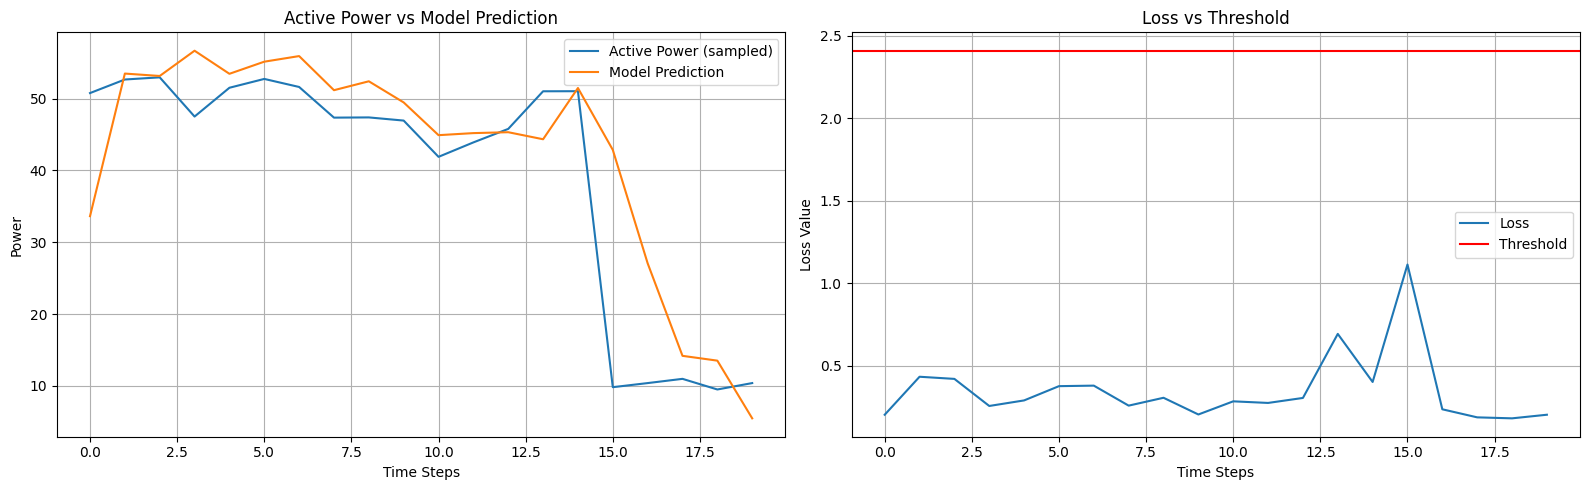

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))  # 1 row, 2 columns

# --- First subplot: Active Power vs Model Prediction ---
axes[0].plot(df_sel[['Active Power']].values[::6], label='Active Power (sampled)')
axes[0].plot(temp_ypreds[0][:, 0], label='Model Prediction')
axes[0].legend()
axes[0].set_title("Active Power vs Model Prediction")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Power")
axes[0].grid(True)

# --- Second subplot: Loss vs Threshold ---
axes[1].plot(loss[:, 0], label='Loss')
axes[1].axhline(y=model_thr_temp[0], color='r', linestyle='-', label='Threshold')
axes[1].legend()
axes[1].set_title("Loss vs Threshold")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Loss Value")
axes[1].grid(True)

plt.tight_layout()
plt.show()


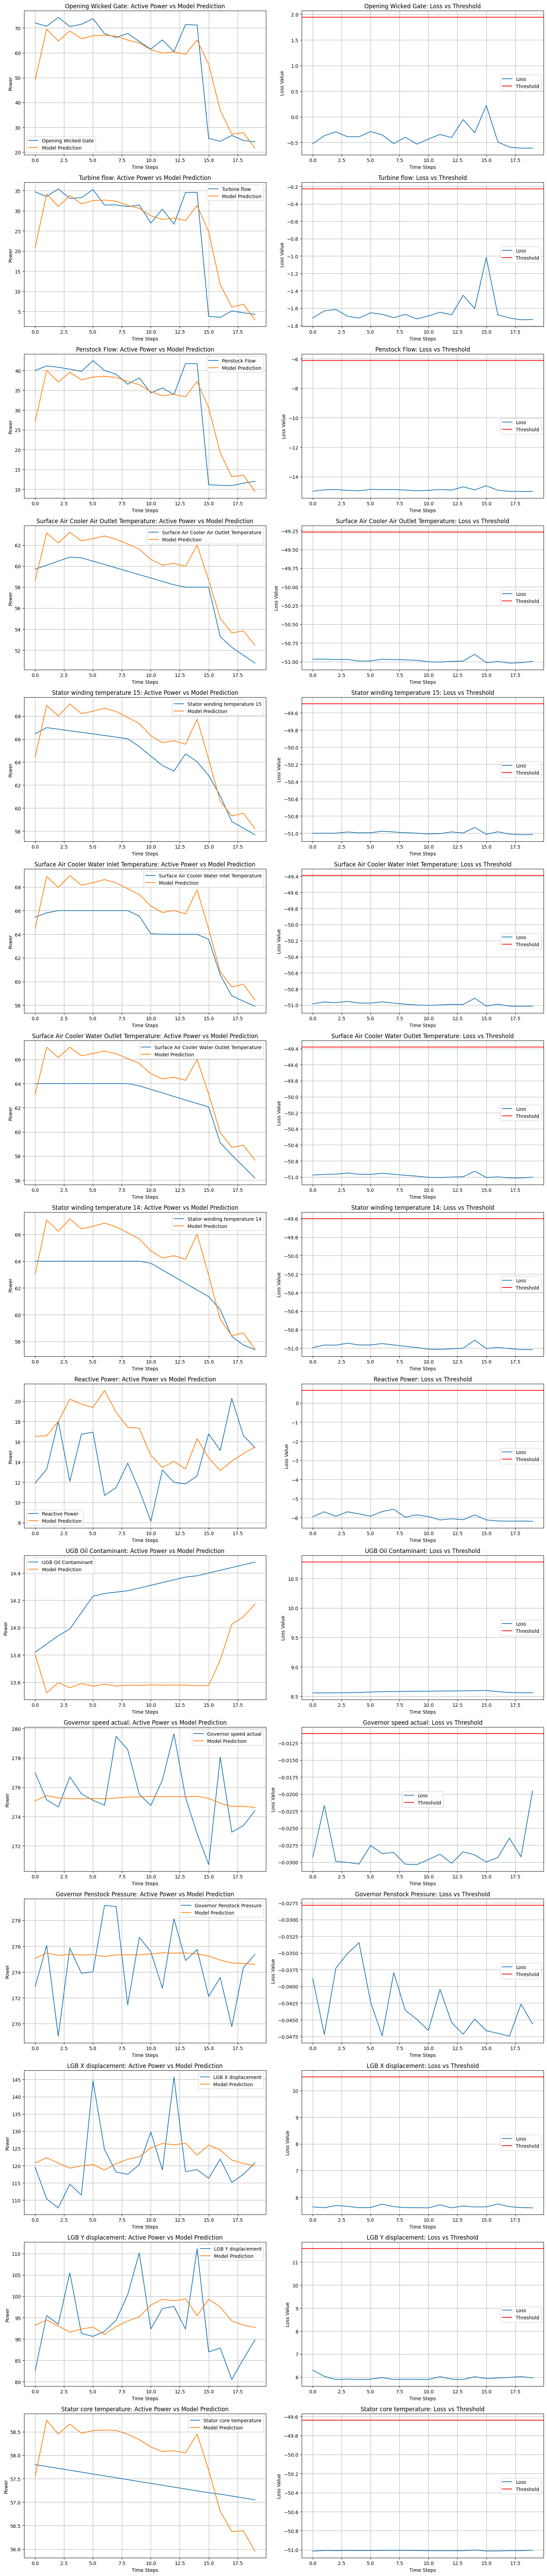

In [45]:
n_rows = len(result['Active Power'])
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))

if n_rows == 1:
    axes = [axes]

for i, correlate_meta in enumerate(result['Active Power']):
    feature_now = list(correlate_meta.keys())[0]
    feature_nowindex = feature_set.index(feature_now)

    # --- Left plot: Active Power vs Model Prediction ---
    axes[i][0].plot(df_sel[[feature_now]].values[::6], label=f'{feature_now}')
    axes[i][0].plot(temp_ypreds[5][:, feature_nowindex], label='Model Prediction')
    axes[i][0].legend()
    axes[i][0].set_title(f"{feature_now}: Active Power vs Model Prediction")
    axes[i][0].set_xlabel("Time Steps")
    axes[i][0].set_ylabel("Power")
    axes[i][0].grid(True)

    # --- Right plot: Loss vs Threshold ---
    axes[i][1].plot(loss[:, feature_nowindex], label='Loss')
    axes[i][1].axhline(y=model_thr_temp[feature_nowindex], color='r', linestyle='-', label='Threshold')
    axes[i][1].legend()
    axes[i][1].set_title(f"{feature_now}: Loss vs Threshold")
    axes[i][1].set_xlabel("Time Steps")
    axes[i][1].set_ylabel("Loss Value")
    axes[i][1].grid(True)

plt.tight_layout()
plt.show()

In [29]:
for correlate_meta in result['Active Power']:
    feature_now = list(correlate_meta.keys())[0]
    feature_nowindex = feature_set.index(feature_now)

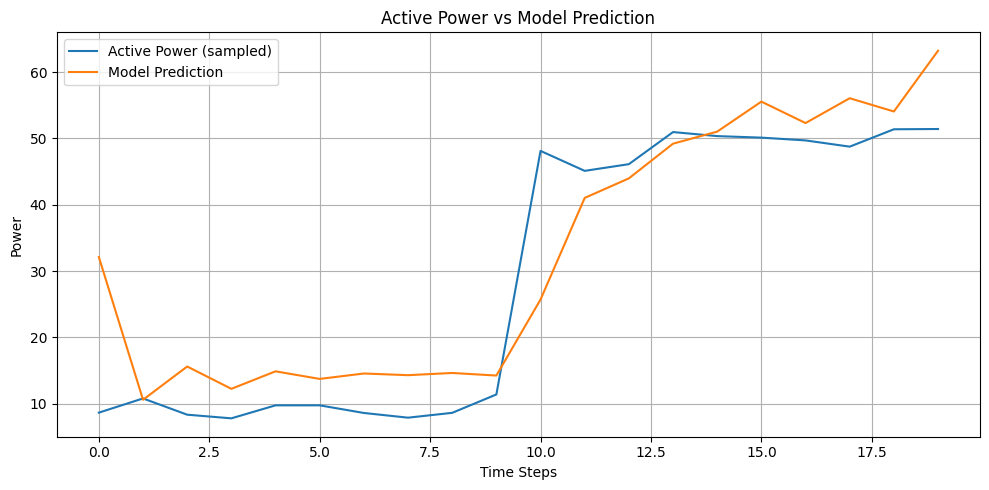

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(df_sel[['Active Power']].values[::6], label='Active Power (sampled)')
plt.plot(temp_ypreds[0][:, feature_nowindex], label='Model Prediction')

plt.legend()
plt.title("Active Power vs Model Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Power")
plt.grid(True)
plt.tight_layout()
plt.show()

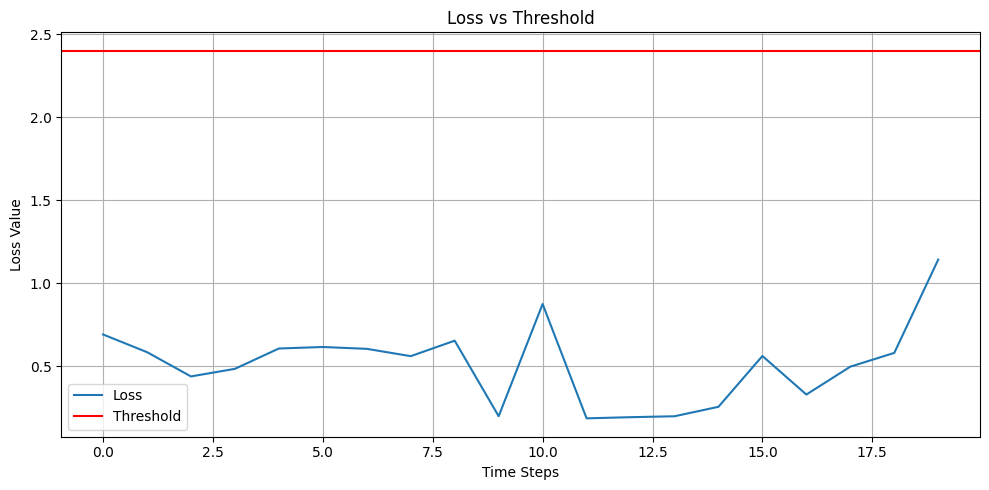

In [20]:
plt.figure(figsize=(10, 5))  # Optional for better visibility

plt.plot(loss[:, 0], label='Loss')
plt.axhline(y=model_thr_temp[0], color='r', linestyle='-', label='Threshold')

plt.legend()
plt.title("Loss vs Threshold")
plt.xlabel("Time Steps")
plt.ylabel("Loss Value")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_20326/3954588875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel.drop('Load Label', axis=1, inplace=True)


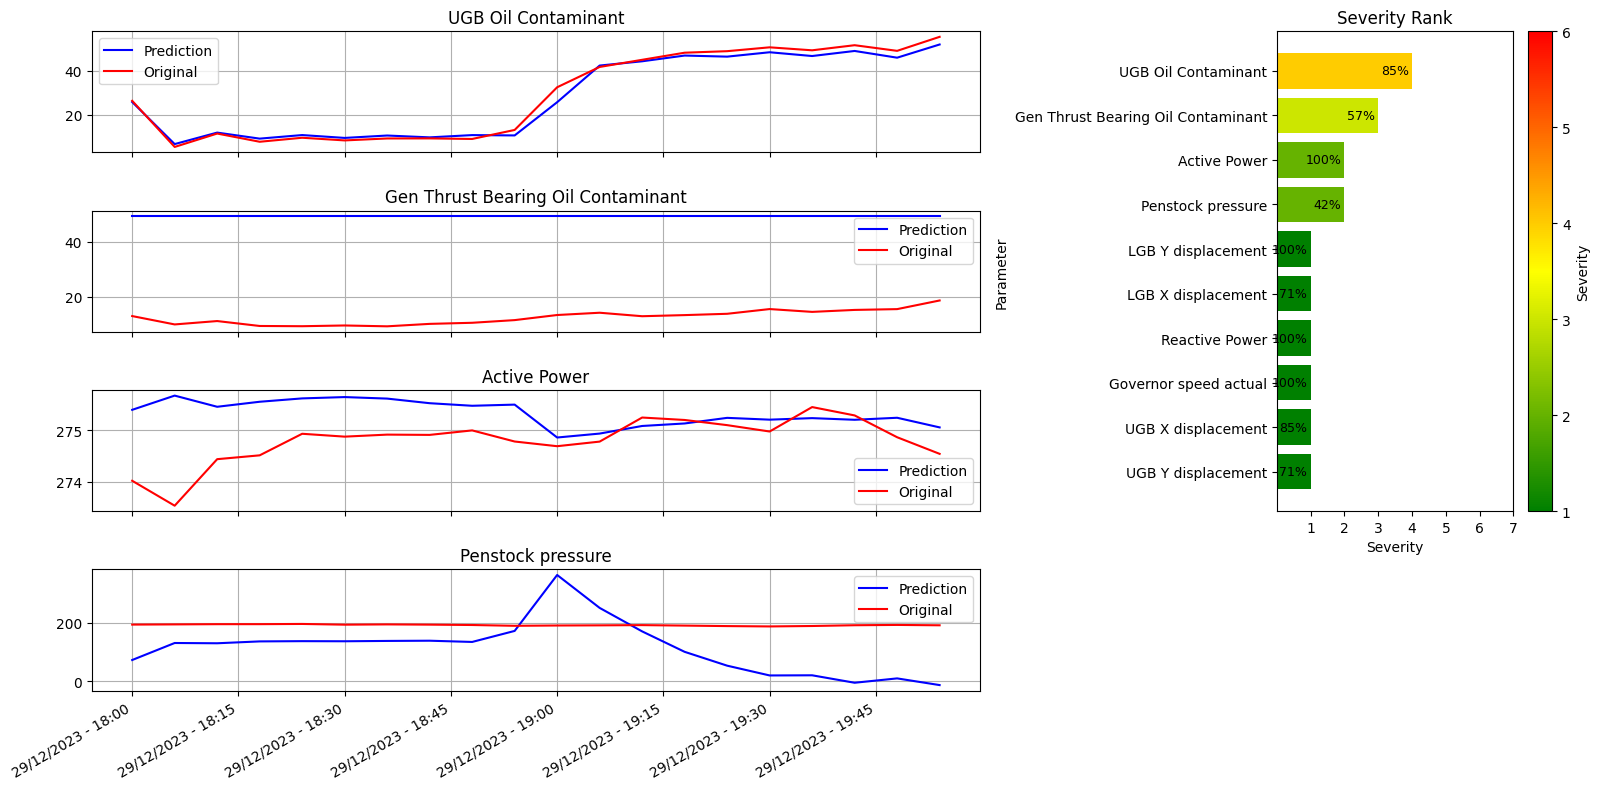

In [ ]:
start_time, end_time = valid_pairs[-1]
window_end = end_time + pd.Timedelta(hours=1)

df_sel = df_data_withtime[(df_data_withtime['TimeStamp'] >= start_time) & (df_data_withtime['TimeStamp'] < window_end)]
df_sel.drop('Load Label', axis=1, inplace=True)
df_sel = df_sel.reset_index(drop=True)
df_sel = df_sel[['TimeStamp'] + feature_set]

threshold_percentages = {}
temp_ypreds = {}
testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)
threshold_percentages, temp_ypreds = calcThres_allModel(threshold_percentages, temp_ypreds, model_array, testD, testO)

y_loss = (df_feature - temp_ypreds[0]) ** 2

df_feature = resample(denormalize3(df_feature, min_a, max_a), 20, axis=0)
df_timestamp = df_timestamp.dt.floor("min")[::6].values
for i in range(len(model_array)):
    temp_ypreds[i] = resample(temp_ypreds[i], 20, axis=0)

counter_feature_s2, counter_feature_plot = calc_counterPercentage(threshold_percentages)
fig = do_plotSeverityRank() 

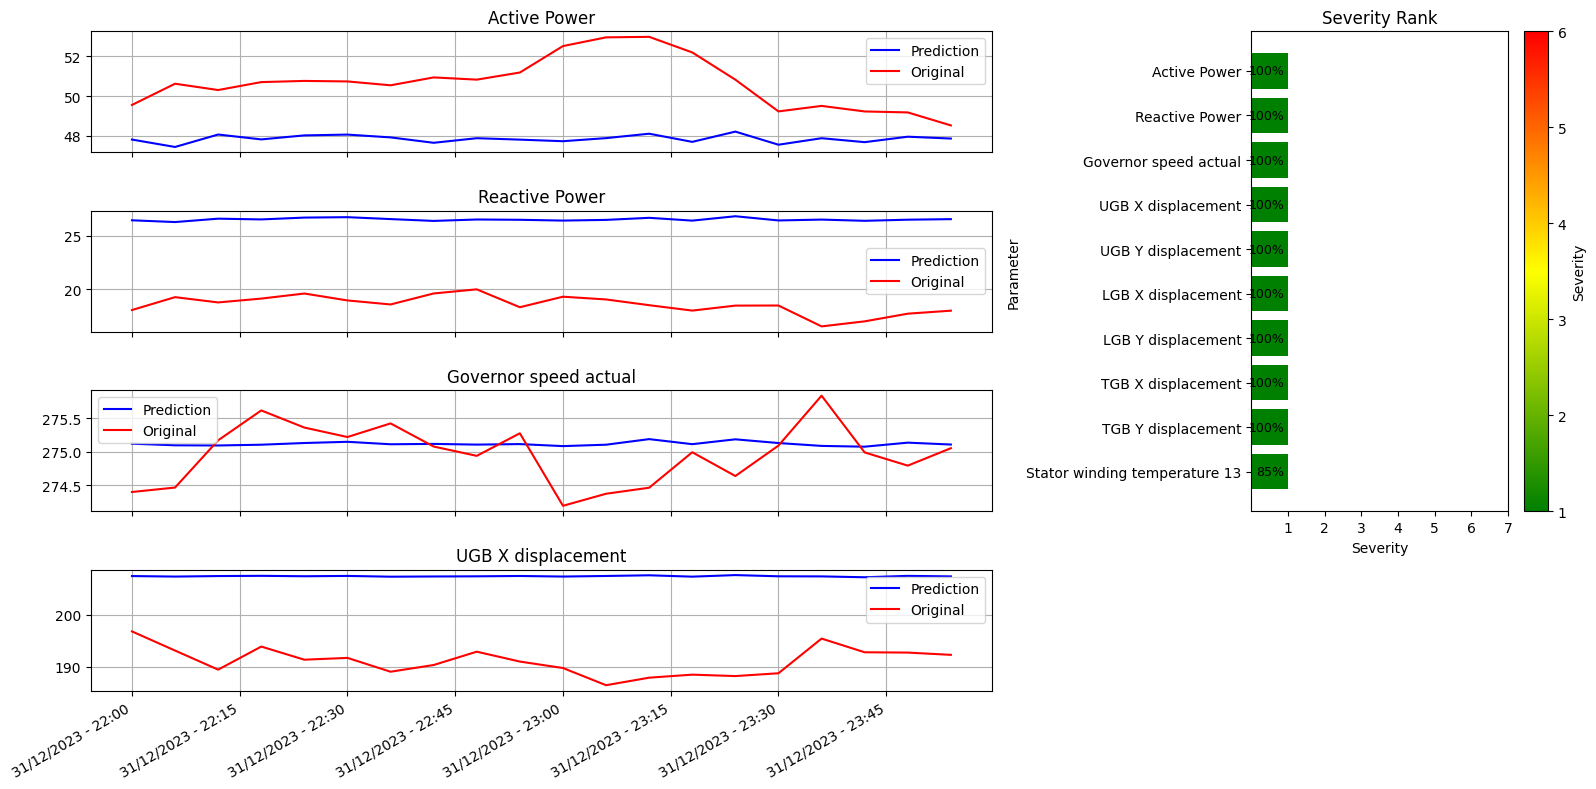

In [33]:
start_time, end_time = valid_pairs[-1]
window_end = end_time + pd.Timedelta(hours=1)

df_sel = df_data_withtime[(df_data_withtime['TimeStamp'] >= start_time) & (df_data_withtime['TimeStamp'] < window_end)]
df_sel = df_sel.reset_index(drop=True)
df_sel.drop('Load Label', axis=1, inplace=True)
df_sel['TimeStamp'] = pd.to_datetime(df_sel['TimeStamp'])
for col in df_sel.columns:
    try:
        if col != 'TimeStamp':
            df_sel[col] = pd.to_numeric(df_sel[col])
    except:
        pass

threshold_percentages = {}
temp_ypreds = {}
testD, testO, df_timestamp, df_feature = preprocessPD_loadData(df_sel)
threshold_percentages, temp_ypreds = calcThres_allModel(threshold_percentages, temp_ypreds, model_array, testD, testO)

df_feature = resample(denormalize3(df_feature, min_a, max_a), 20, axis=0)
df_timestamp = df_timestamp.dt.floor("min")[::6].values
for i in range(len(model_array)):
    temp_ypreds[i] = resample(temp_ypreds[i], 20, axis=0)

counter_feature_s2, counter_feature_plot = calc_counterPercentage(threshold_percentages)
fig = do_plotSeverityRank() 

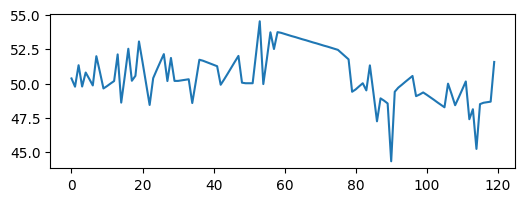

In [17]:
plt.plot(last_pair_df[['Active Power']].values)

In [ ]:
Hour 1: 2023-12-31 16:00:00 | Hour 2: 2023-12-31 17:00:00